In [2]:
# coding: utf-8
# наше всё
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from pylab import rcParams

# настройки pandas, с которыми лучше почти всегда
pd.set_option('display.max_rows', 45000)
pd.set_option('display.max_columns', 50000)
pd.set_option('display.max_colwidth', 5000)

# графики в svg выглядят более четкими
%config InlineBackend.figure_format = 'svg' 
rcParams['figure.figsize'] = 16, 12

In [3]:
source_df = pd.read_excel('qval4.xlsx', sheet_name='Worksheet')

In [4]:
res_df = source_df.copy()
diff_df = res_df.copy()
for i in range(1, len(diff_df.columns)-2):
    diff_df[i] = np.sum(diff_df[i]) / len(diff_df[i])



pot_df = res_df.copy()
for i in range(1, len(diff_df.columns)-2):
    pot_df[i] = diff_df[i] * res_df[i]


diff_df = diff_df[0:1][diff_df.columns[3:]].T
diff_df = diff_df.reset_index()
diff_df.columns = ['question', 'difficulty']


In [5]:
diff_df.sample(3)

,question,difficulty
33,34,0.535714
29,30,0.428571
28,29,0.142857


In [6]:
diff_df.sort_values(by='difficulty', ascending=False)[0:3]

,question,difficulty
8,9,1.000000
3,4,0.964286
12,13,0.964286


In [7]:
diff_df.sort_values(by='difficulty', ascending=True)[0:3]

,question,difficulty
24,25,0.071429
1,2,0.107143
28,29,0.142857


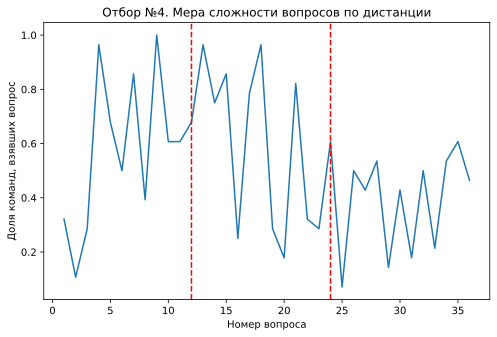

In [8]:
plt.figure(figsize=(8, 5))
sns.lineplot(data=diff_df, x='question', y='difficulty')
plt.xlabel('Номер вопроса')
plt.ylabel('Доля команд, взявших вопрос')
plt.title('Отбор №4. Мера сложности вопросов по дистанции')
#  вертикальная линия при x = 12 и x = 24
plt.axvline(x=12, color='red', linestyle='--')
plt.axvline(x=24, color='red', linestyle='--')
plt.show()


<Figure size 800x500 with 0 Axes>

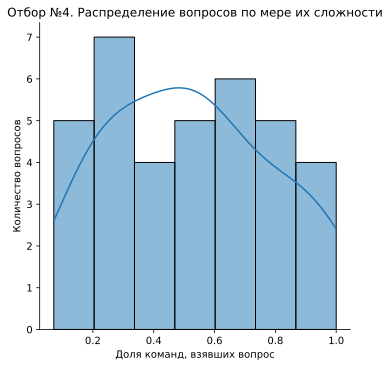

In [9]:
plt.figure(figsize=(8, 5))
sns.displot(diff_df['difficulty'], kde=True)
plt.xlabel('Доля команд, взявших вопрос')
plt.ylabel('Количество вопросов')
plt.title('Отбор №4. Распределение вопросов по мере их сложности')
plt.show()






In [10]:
team_stat = res_df[res_df.columns[0:3]].copy()
team_stat['result'] = np.sum(res_df[res_df.columns[3:]], axis=1)
team_stat['difficulty'] = np.sum(pot_df[pot_df.columns[3:]], axis=1)
team_stat['potential'] = team_stat['difficulty'] / team_stat['result']


In [11]:
team_stat.sort_values(by='result', ascending=False)

,Team ID,Название,Город,result,difficulty,potential
1,107857,ОКДФ ли?,Москва,29,16.535714,0.570197
16,107859,Дмитровские диплодоки,Москва,29,16.857143,0.581281
25,54199,Улыбаемся и пашем,Москва,29,17.000000,0.586207
0,61155,Двоичный кот,Москва,27,16.928571,0.626984
3,96318,Батрахоспермум,Москва,27,16.642857,0.616402
6,102419,Название потом придумаем,Москва,26,14.892857,0.572802
13,102417,Регулярно ОКДФ,Москва,25,15.535714,0.621429
8,72953,Бегом Домой Смотреть Мультики,Москва,24,14.964286,0.623512
17,107860,"Yasha, lava!",Москва,24,14.750000,0.614583
7,54173,Маргарита с ананасами,Москва,24,15.142857,0.630952


In [12]:
team_stat[['result']].describe()

,result
count,28.000000
mean,18.678571
std,7.170173
min,4.000000
25%,12.750000
50%,18.500000
75%,24.250000
max,29.000000


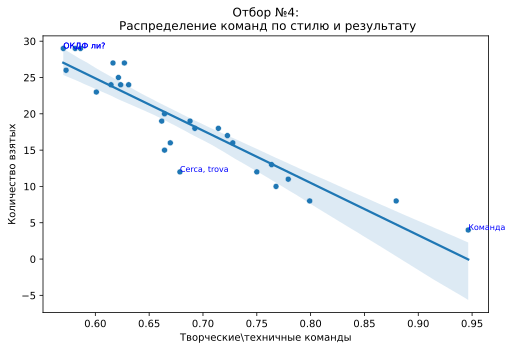

In [35]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=team_stat, 
    x="potential", 
    y="result",
    )

plt.title("Отбор №4:\n Распределение команд по стилю и результату")
# add a trend line
sns.regplot(data=team_stat, x="potential", y="result", scatter=False)

# add points
x1 = np.min(team_stat['potential'])
y1 = team_stat[team_stat['potential'] == x1]['result'].values[0]
name1 = team_stat[team_stat['potential'] == x1]['Название'].values[0]
plt.text(x1, y1, name1, fontsize=8, color='blue')

x2 = np.max(team_stat['potential'])
y2 = team_stat[team_stat['potential'] == x2]['result'].values[0]
name2 = team_stat[team_stat['potential'] == x2]['Название'].values[0]
plt.text(x2, y2, name2, fontsize=8, color='blue')

y3 = np.max(team_stat['result'])
x3 = team_stat[team_stat['result'] == y3]['potential'].values[0]
name3 = team_stat[team_stat['result'] == y3]['Название'].values[0]
plt.text(x3, y3, name3, fontsize=8, color='blue')

# y4 = np.min(team_stat['result'])
# x4 = team_stat[team_stat['result'] == y4]['potential'].values[0]
# name4 = team_stat[team_stat['result'] == y4]['Название'].values[0]
# plt.text(x4, y4, name4, fontsize=8, color='blue')

x5 = team_stat['potential'].values[np.random.randint(0, len(team_stat))]
y5 = team_stat[team_stat['potential'] == x5]['result'].values[0]
name5 = team_stat[team_stat['potential'] == x5]['Название'].values[0]
plt.text(x5, y5, name5, fontsize=8, color='blue')

plt.xlabel("Творческие\техничные команды")
plt.ylabel("Количество взятых")

plt.show()


In [14]:
# сильные техничные команды
team_stat[
    (team_stat['potential'] > np.mean(team_stat['potential'])) & 
    (team_stat['result'] > np.mean(team_stat['result']))
]['Название']

14    Диванные знатоки
Name: Название, dtype: object

In [15]:
# сильные творческие команды
team_stat[
    (team_stat['potential'] < np.mean(team_stat['potential'])) & 
    (team_stat['result'] > np.mean(team_stat['result']))
]['Название']

0                      Двоичный кот
1                          ОКДФ ли?
3                    Батрахоспермум
5                         Соратники
6          Название потом придумаем
7             Маргарита с ананасами
8     Бегом Домой Смотреть Мультики
10                     Ирис Кис-Кис
13                   Регулярно ОКДФ
15                     Два капитана
16            Дмитровские диплодоки
17                     Yasha, lava!
25                Улыбаемся и пашем
Name: Название, dtype: object

In [16]:
team_stat.sort_values(by='potential', ascending=True)[0:5]

,Team ID,Название,Город,result,difficulty,potential
1,107857,ОКДФ ли?,Москва,29,16.535714,0.570197
6,102419,Название потом придумаем,Москва,26,14.892857,0.572802
16,107859,Дмитровские диплодоки,Москва,29,16.857143,0.581281
25,54199,Улыбаемся и пашем,Москва,29,17.000000,0.586207
15,93000,Два капитана,Москва,23,13.821429,0.600932


In [17]:
team_stat.sort_values(by='potential', ascending=False)[0:5]

,Team ID,Название,Город,result,difficulty,potential
21,57674,Команда,Москва,4,3.785714,0.946429
24,96014,Баклажан наД АркОй,Москва,8,7.035714,0.879464
18,107861,Los bandidos,Москва,8,6.392857,0.799107
11,104412,Медуза распустилась совсем,Москва,11,8.571429,0.779221
22,107544,Тамбовский Волк,Москва,10,7.678571,0.767857


In [18]:
team_qv_df = res_df.melt(
    id_vars=['Название', 'Город', 'Team ID'],
    value_vars=res_df.columns[3:],
    var_name='question',
    value_name='qv_result'
)
team_qv_df = team_qv_df.merge(
    diff_df, 
    'left',
    on='question'
)
team_qv_df = team_qv_df.merge(
    team_stat,
    'left',
    on=['Название', 'Team ID', 'Город'],
    suffixes=('_qv', '_total')
)
team_qv_df['epic'] = team_qv_df['result'] * team_qv_df['difficulty_qv']




In [19]:
# топ эпических взятий
team_qv_df[team_qv_df['qv_result'] == 1].sort_values(by='epic', ascending=True)[0:3]

,Название,Город,Team ID,question,qv_result,difficulty_qv,result,difficulty_total,potential,epic
676,"Cerca, trova",Москва,104632,25,1,0.071429,12,8.142857,0.678571,0.857143
54,Смех не грех,Москва,107736,2,1,0.107143,16,10.714286,0.669643,1.714286
678,Название потом придумаем,Москва,102419,25,1,0.071429,26,14.892857,0.572802,1.857143


In [20]:
# топ эпических продолбов
team_qv_df[team_qv_df['qv_result'] == 0].sort_values(by='epic', ascending=False)[0:4]

,Название,Город,Team ID,question,qv_result,difficulty_qv,result,difficulty_total,potential,epic
169,ОКДФ ли?,Москва,107857,7,0,0.857143,29,16.535714,0.570197,24.857143
463,Два капитана,Москва,93000,17,0,0.785714,23,13.821429,0.600932,18.071429
314,Название потом придумаем,Москва,102419,12,0,0.678571,26,14.892857,0.572802,17.642857
315,Маргарита с ананасами,Москва,54173,12,0,0.678571,24,15.142857,0.630952,16.285714


In [21]:
res_df = res_df.merge(
    team_stat,
    'left',
    on=['Название', 'Team ID', 'Город'],
    suffixes=('_qv', '_total')
)
res_df.sample(3)


,Team ID,Название,Город,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,result,difficulty,potential
19,107862,Врачебный барак Обама 1433,Москва,0,0,0,1,1,0,0,0,1,1,1,0,1,0,1,0,1,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,13,9.928571,0.763736
1,107857,ОКДФ ли?,Москва,1,0,1,1,1,0,0,1,1,1,1,1,1,1,1,0,1,1,1,0,1,1,1,1,0,1,1,1,1,1,0,1,1,1,1,1,29,16.535714,0.570197
2,92020,Дочери Деметры,Москва,0,0,0,1,1,0,1,0,1,0,1,1,1,0,1,0,1,1,0,0,1,0,1,1,0,0,0,1,0,0,0,1,0,1,0,0,16,11.642857,0.727679


In [22]:
# корреляция между столбцам в data frame
correlations_with_result = pd.DataFrame(res_df[res_df.columns[3:-2]].corr()['result'])
correlations_with_result.columns = ['correlation']
correlations_with_result.sort_values(by='correlation', ascending=False)[0:7]

,correlation
result,1.000000
26,0.765925
8,0.753353
35,0.721453
22,0.715662
3,0.691332
34,0.689790


In [23]:
correlations_with_result.sort_values(by='correlation', ascending=True)[0:5]

,correlation
25,0.012661
2,0.032214
4,0.073213
7,0.082831
18,0.182545


In [24]:
res_df.sample(3)

,Team ID,Название,Город,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,result,difficulty,potential
7,54173,Маргарита с ананасами,Москва,0,0,0,1,1,1,1,1,1,1,1,0,1,1,1,0,1,1,1,0,1,1,0,1,0,1,1,1,0,1,0,0,1,0,1,1,24,15.142857,0.630952
2,92020,Дочери Деметры,Москва,0,0,0,1,1,0,1,0,1,0,1,1,1,0,1,0,1,1,0,0,1,0,1,1,0,0,0,1,0,0,0,1,0,1,0,0,16,11.642857,0.727679
14,104735,Диванные знатоки,Москва,0,1,0,1,1,1,1,0,1,1,1,1,1,1,1,0,1,1,0,0,1,0,0,0,0,1,0,1,0,1,0,0,0,0,0,1,19,13.071429,0.687970


In [25]:
top_3 = list(correlations_with_result.sort_values(by='correlation', ascending=False)[1:4].index)
top_5 = list(correlations_with_result.sort_values(by='correlation', ascending=False)[1:6].index)

In [26]:
res_df['top-3'] = np.sum(res_df[res_df.columns[res_df.columns.isin(top_3)]], axis=1)
res_df['top-5'] = np.sum(res_df[res_df.columns[res_df.columns.isin(top_5)]], axis=1)
res_df.sample(3)






,Team ID,Название,Город,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,result,difficulty,potential,top-3,top-5
25,54199,Улыбаемся и пашем,Москва,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,1,1,1,1,0,1,1,1,1,0,0,0,0,1,1,1,29,17.000000,0.586207,3,5
7,54173,Маргарита с ананасами,Москва,0,0,0,1,1,1,1,1,1,1,1,0,1,1,1,0,1,1,1,0,1,1,0,1,0,1,1,1,0,1,0,0,1,0,1,1,24,15.142857,0.630952,3,4
10,104740,Ирис Кис-Кис,Москва,0,0,0,1,0,1,1,0,1,0,1,1,1,1,1,0,1,1,0,1,1,0,1,1,0,0,1,1,0,0,1,0,0,0,1,0,19,12.571429,0.661654,1,1


In [27]:
res_df[['top-3', 'top-5', 'result']].corr()

,top-3,top-5,result
top-3,1.000000,0.96327,0.911708
top-5,0.963270,1.00000,0.913740
result,0.911708,0.91374,1.000000
